In [72]:
import pandas as pd
import numpy as np
#from config_ import *

named13C_cellulose = "δ13C (‰ v.s.V-PDB)" ### Exceptional 
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"

# Sumaco cleaning
data only from 2026



# Resultados Julio 2025

In [73]:
#CELLULOSA
celulosa = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea-Cellulose-13C-202603.xlsx")
#275
celulosa[["plot","tree"]] = celulosa["Sample-ID"].str.split("-",expand=True)

In [74]:
#se homogeniza
celulosa["plot"]=celulosa["plot"].str.replace("p", "", regex=False)

celulosa["plot"] = celulosa["plot"].apply(
    lambda x: str(x).zfill(2) if str(x).isdigit() else x
)
celulosa["Sample-ID"] = "p"+celulosa["plot"]+"-"+celulosa["tree"]
celulosa["Sample-ID"] = celulosa["Sample-ID"].replace({
    "p9-231":"p09-231","p9-233":"p09-233","p9-235":"p09-235","p9-225":"p09-225","p9-230":"p09-230",
    "p10-3694":"p11-3694",
    "p10-3699":"p11-3699",
    "p18-3745":"p16-3745",
    "p08-3770":"p18-3770",
    "p9-3732":"p09-3732",
 "p9-3730":"p09-3730",
 "p9-3734":"p09-3734",
 "p9-3733":"p09-3733",
 "p9-3735":"p09-3735",
 "p9-3729":"p09-3729",
 "p9-3728":"p09-3728",
 "p11-3796":"p11-3696",
 "p18-3669":"p18-3769", #en esta linea no existe 18 con 36
 "p11-3701":"p11-3707",
  "p01-230":"p09-230" #no se colecto 3701
}) #missing 3703, p10-252, p12-304, p13-315
plots = ["p09","p9","09","p10","10","p11","11","p12","12","p13","13","p16","16","p18","18"] #todos

df_filtrado = celulosa[celulosa["Sample-ID"].str.contains("|".join(plots), na=False)] #hay unas muestras que hay que limpiar
df_filtrado.to_excel("filtrado.xlsx")


In [75]:
sumaco_2006 = pd.read_excel("Sumaco_samples 2006.xlsx")
sumaco_2006["plot ID"] = sumaco_2006["plot ID"].astype(str).str.replace("SUM_", "p", regex=False)
sumaco_2006["Sample-ID"]=sumaco_2006["plot ID"]+"-"+sumaco_2006["treeID"].astype(str)
sumaco_2006 = sumaco_2006[["Sample-ID","family","genus","species"]]


In [76]:

SUM_2006 = pd.merge(sumaco_2006,df_filtrado, on="Sample-ID",how="left",indicator=True) #revisar q más se puede rescatar
SUM_2006 = SUM_2006.rename(columns={"plot":"Plot","tree":"old_treeID","[C] m/m in %":nameC_cellulose,
                                   "δ13C (‰ v.s. V-PDB)":named13C_cellulose })
SUM_2006 = SUM_2006.drop(columns={"nr of samples","Batch","_merge"})
SUM_2006["Year"]=2006 #Le falta las ID del 2025
SUM_2006

,Sample-ID,family,genus,species,[C]%,δ13C (‰ v.s.V-PDB),Plot,old_treeID,Year
0,p09-225,Moraceae,Ficus,quijosana,42.578188,-28.691043,09,225,2006
1,p09-230,Lauraceae,Ocotea,insularis,45.456318,-29.289822,01,230,2006
2,p09-231,Clusiaceae,Clusia,NaN,45.788101,-29.783344,09,231,2006
3,p09-233,Icacinaceae,Calatola,costaricensis,NaN,NaN,NaN,NaN,2006
4,p09-235,Icacinaceae,Calatola,costaricensis,43.261474,-30.191463,09,235,2006
5,p10-238,Clusiaceae,Chrysochlamys,membranacea,43.175043,-29.177724,10,238,2006
6,p10-239,Moraceae,Ficus,cuatrecasana,44.334499,-28.667583,10,239,2006
7,p10-240,Lauraceae,Persea,areolatocostae,44.245873,-27.855772,10,240,2006
8,p10-241,Verbenaceae,Aegiphila,NaN,44.380000,-28.450000,10,241,2006
9,p10-242,Solanaceae,Solanum,cf anisophyllum,42.914146,-29.621863,10,242,2006


Aca estan la base con los datos de old tree y new tree id para unir

In [77]:
#no_unidos = SUM_2006[SUM_2006["_merge"] == "right_only"]
#no_unidos

sumaco_2006_newtag = pd.read_excel("Sumaco_17092025.xlsx", sheet_name="final") #queremos los  new ID
sumaco_2006_newtag = sumaco_2006_newtag[["plot ID","treeID","new tree ID 2025","collection"]]
sumaco_2006_newtag["plot ID"] = sumaco_2006_newtag["plot ID"].astype(str).str.replace("SUM_", "p", regex=False)
sumaco_2006_newtag["Sample-ID"]=sumaco_2006_newtag["plot ID"]+"-"+sumaco_2006_newtag["treeID"].astype(str)#uso la oldId porque con algunas nuevas no funciona muy bien


In [78]:
### Here we add the new IDS
test_2006 = pd.merge(SUM_2006,sumaco_2006_newtag,how="left",on="Sample-ID")
SUM_2006 = test_2006.drop(columns={"old_treeID","plot ID"}).rename(columns={"treeID":"old_treeID","new tree ID 2025":"new_TreeID","collection":"JH herbarium collections"})
SUM_2006.head(2)

,Sample-ID,family,genus,species,[C]%,δ13C (‰ v.s.V-PDB),Plot,Year,old_treeID,new_TreeID,JH herbarium collections
0,p09-225,Moraceae,Ficus,quijosana,42.578188,-28.691043,09,2006,225,NaN,NaN
1,p09-230,Lauraceae,Ocotea,insularis,45.456318,-29.289822,01,2006,230,NaN,3343


In [79]:
sumaco_2025 = pd.read_excel("Sumaco_17092025.xlsx",sheet_name="Rasgos_2025")
sumaco_2025 = sumaco_2025[["plot ID","treeID","new tree ID 2025","family","genus","species"]]
sumaco_2025["plot ID"] = sumaco_2025["plot ID"].astype(str).str.replace("SUM_", "p", regex=False)
sumaco_2025["Sample-ID"]=sumaco_2025["plot ID"]+"-"+sumaco_2025["new tree ID 2025"].astype(str)


In [80]:
SUM_2025 = pd.merge(sumaco_2025,df_filtrado, on="Sample-ID",how="left") #revisar q más se puede rescatar
SUM_2025 = SUM_2025.rename(columns={"plot ID":"Plot","treeID":"old_treeID","new tree ID 2025":"new_TreeID",
                                    "[C] m/m in %":nameC_cellulose,
                                   "δ13C (‰ v.s. V-PDB)":named13C_cellulose })
SUM_2025 = SUM_2025.drop(columns={"nr of samples","Batch","plot","tree"})
SUM_2025["Year"]=2025
SUM_2025.head(2)#.to_excel("test.xlsx")

,Plot,old_treeID,new_TreeID,family,genus,species,Sample-ID,[C]%,δ13C (‰ v.s.V-PDB),Year
0,p09,233,3730,Metteniusaceae,Calatola,costaricensis,p09-3730,46.64,-30.84,2025
1,p09,235,3733,Metteniusaceae,Calatola,costaricensis,p09-3733,47.83,-30.50,2025


Unir Miscelanea

In [81]:
mis2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Report 13C-pq4.xlsx")
mis2026["Sample ID"] =  mis2026["Sample ID"].astype(str).replace({"320":"p13-320","3886":"p12-3686"}) ### REVISAR HELP 3886 no existe, pero si 3686 que es de SUMACO

mis2026 = mis2026.rename(columns={"Sample ID":"Sample-ID"})#arriba todo con guion
mis2026 = mis2026.rename(columns={"[C] m/m":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

patrones = ["09","10","13","11","12","16","18"]
regex = r"^p(" + "|".join(patrones) + r")-"
mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo SUMACO
mis2026= mis2026[["Sample-ID",nameC_cellulose,named13C_cellulose]]
#### separamos los de parcelas
mis2026= mis2026[mis2026["Sample-ID"] != "p09-176-ctrl"]

mis2026.loc[mis2026["Sample-ID"] == "p10-241", ["old_treeID","new_TreeID","Plot"]] = [241,8878,10]
mis2026.loc[mis2026["Sample-ID"] == "p09-233", ["old_treeID","new_TreeID","Plot"]] = [233,8885,9]
mis2026.loc[mis2026["Sample-ID"] == "p10-3715", ["new_TreeID","Plot"]] = [8885,10]
mis2026.loc[mis2026["Sample-ID"] == "p12-3686", ["new_TreeID","Plot"]] = [3686, 12]
mis2026.loc[mis2026["Sample-ID"] == "p13-320", ["old_treeID","new_TreeID","Plot"]] = [320,3715, 13]


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_7120\4119884594.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo SUMACO


In [82]:
big_df = pd.concat([SUM_2006,SUM_2025])


In [83]:

#aqui se usa los datos de la  miscelanea
new_data = pd.DataFrame({
    "Sample-ID": ["p13-320", "p10-241", "p09-233", "p12-3686", "p10-3715"],
    "[C]%": [0.4266, 0.4162, 0.4733, 0.4353, 0.3669],
    "δ13C (‰ v.s.V-PDB)": [-25.52, -28.75, -29.45, -33.73, -29.13],
    "old_treeID": [320.0, 241.0, 233.0, np.nan, np.nan],
    "new_TreeID": [3715.0, 8878.0, 8885.0, 3686.0, 8885.0],
    "Plot": [13.0, 10.0, 9.0, 12.0, 10.0],
})

existing_ids = set(big_df["Sample-ID"])
to_update = new_data[new_data["Sample-ID"].isin(existing_ids)].copy()
to_append = new_data[~new_data["Sample-ID"].isin(existing_ids)].copy()

print("Updating:", list(to_update["Sample-ID"]))
print("Appending:", list(to_append["Sample-ID"]))

# --- 1. update the 4 existing rows ---
big_df = big_df.set_index("Sample-ID")
to_update = to_update.set_index("Sample-ID")

for col in to_update.columns:
    if col not in big_df.columns:
        big_df[col] = np.nan

big_df.update(to_update)
big_df = big_df.reset_index()

# --- 2. append the 1 new row (p12-3686) ---
big_df = pd.concat([big_df, to_append], ignore_index=True, sort=False)
results_celulosa=big_df
results_celulosa["PlotID"]="SUM_"+results_celulosa["Plot"].astype(str)
results_celulosa.to_excel("Sumaco_cellulose.xlsx")

Updating: ['p13-320', 'p10-241', 'p09-233', 'p10-3715']
Appending: ['p12-3686']


### Faltan los resultados del bulk

# Graficos para probar

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
import calculate_iWUE_sum
import elevation_dict
%run calculate_iWUE_sum
%run elevation_dict

df = results_celulosa.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)
df["Site"]="Sumaco"


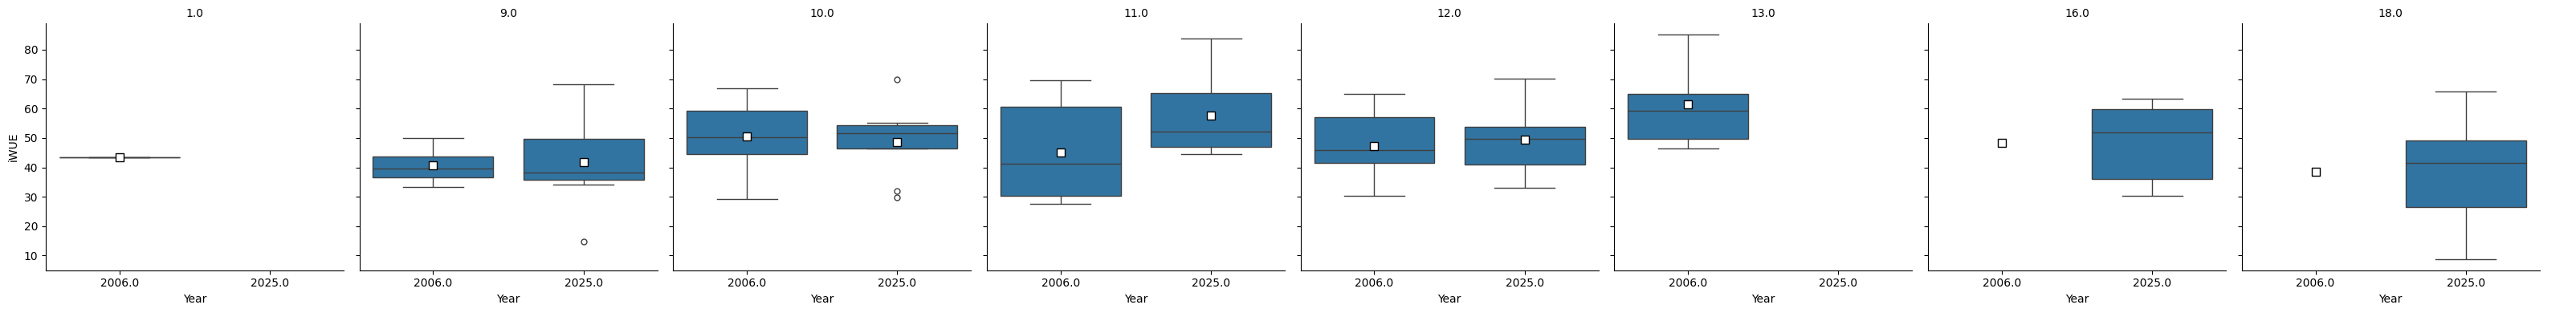

In [85]:
df["Plot"] = (
    df["Plot"]
    .astype(str)
    .str.replace("p", "", regex=False)
)

df["Plot"] = df["Plot"].astype("float64")

df.to_excel("test.xlsx")

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Plot",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

for ax in g.axes.flat:
    # obtener el valor de Elevation de este subplot
    plot = ax.get_title().split(" = ")[-1]

    subset = df[df["Plot"].astype(str) == plot]

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean()

    # posiciones en x (0,1,2,...)
    x_positions = range(len(means))

    ax.scatter(
        x_positions,
        means,
        color="white",
        edgecolor="black",
        marker="s",  # cuadrado
        s=60,
        zorder=5
    )
g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

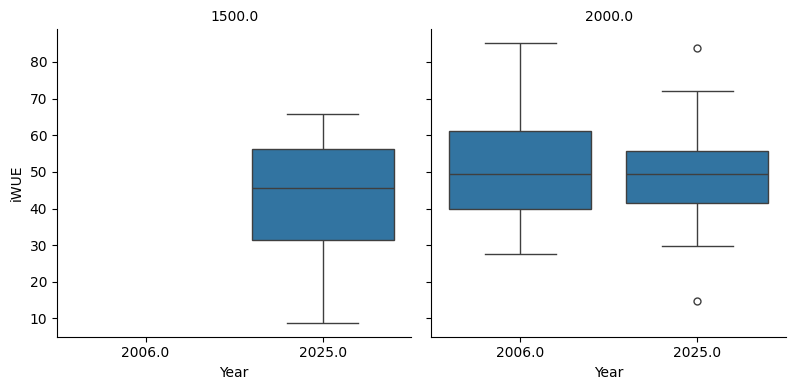

In [86]:
df["Elevation"] = df.set_index(["Site", "Plot"]).index.map(elevation_dict)

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Elevation",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()